# Clase 7 Análisis de Datos

## 20260327

### Librerías

In [158]:
# %pip install yfinance
%pip install pywaffle

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [159]:
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
from pywaffle import Waffle
import re
import math

### Funciones

In [160]:
def sanitize_col(name: str) -> str:
    name = name.upper().replace(" ","_")
    name = re.sub(r"[^A-Z_]","",name)
    name = re.sub(r"_+","_",name).strip("_")
    return name

In [161]:
def get_price_col(ticker):
    col = f"ADJ_CLOSE_{sanitize_col(ticker)}"
    return col


In [162]:
def period_return(series, periods=None, start_date=None):
    s = series.dropna()

    if s.empty:
        return np.nan
    
    end_val = s.iloc[-1]

    if start_date is not None:
        s0 = s[s.index >= pd.Timestamp(start_date)]

        if s0.empty:
            return np.nan
        
        start_val = s0.iloc[0]

    else:

        if periods is None or len(s) <= periods:
            return np.nan

        start_val = s.iloc[-(periods + 1)]

    if pd.isna(start_val) or start_val == 0:
        return np.nan
    
    return(end_val/start_val) - 1

### Ingesta de Datos

In [163]:
tks = ["AAPL","MSFT","AMZN","GOOGL","META","NVDA","TSLA","JPM","JNJ","XOM","^GSPC"]

inicio = "2021-01-01"
final = "2026-01-01"

data = yf.download(tickers = tks, start = inicio, end = final, auto_adjust= False, progress=True, threads = True)

[*********************100%***********************]  11 of 11 completed


### Manipulación y Transformación de Datos

In [164]:
data.columns

MultiIndex([('Adj Close',  'AAPL'),
            ('Adj Close',  'AMZN'),
            ('Adj Close', 'GOOGL'),
            ('Adj Close',   'JNJ'),
            ('Adj Close',   'JPM'),
            ('Adj Close',  'META'),
            ('Adj Close',  'MSFT'),
            ('Adj Close',  'NVDA'),
            ('Adj Close',  'TSLA'),
            ('Adj Close',   'XOM'),
            ('Adj Close', '^GSPC'),
            (    'Close',  'AAPL'),
            (    'Close',  'AMZN'),
            (    'Close', 'GOOGL'),
            (    'Close',   'JNJ'),
            (    'Close',   'JPM'),
            (    'Close',  'META'),
            (    'Close',  'MSFT'),
            (    'Close',  'NVDA'),
            (    'Close',  'TSLA'),
            (    'Close',   'XOM'),
            (    'Close', '^GSPC'),
            (     'High',  'AAPL'),
            (     'High',  'AMZN'),
            (     'High', 'GOOGL'),
            (     'High',   'JNJ'),
            (     'High',   'JPM'),
            (     'High',  '

In [165]:
data

Price        Adj Close                                                  \
Ticker            AAPL        AMZN       GOOGL         JNJ         JPM   
Date                                                                     
2021-01-04  125.856735  159.331497   85.599030  135.059677  110.051918   
2021-01-05  127.412758  160.925507   86.289322  136.647568  110.650757   
2021-01-06  123.123848  156.919006   85.437866  137.933426  115.846428   
2021-01-07  127.325264  158.108002   87.989769  138.399475  119.650726   
2021-01-08  128.424194  159.134995   89.154633  138.114731  119.782829   
...                ...         ...         ...         ...         ...   
2025-12-24  273.554016  232.380005  313.869049  206.681259  327.691864   
2025-12-26  273.144409  232.520004  313.289459  206.532059  326.437531   
2025-12-29  273.504089  232.070007  313.339417  206.462418  322.296204   
2025-12-30  272.824707  232.529999  313.629242  205.815857  321.967712   
2025-12-31  271.605835  230.820007  312.779816  205.855652  320.773071   

Price                                                                   ...  \
Ticker            META        MSFT        NVDA        TSLA         XOM  ...   
Date                                                                    ...   
2021-01-04  266.845947  208.406555   13.076020  243.256668   33.693794  ...   
2021-01-05  268.860138  208.607544   13.366436  245.036667   35.317581  ...   
2021-01-06  261.259766  203.198502   12.578444  251.993332   36.218788  ...   
2021-01-07  266.647461  208.980927   13.305861  272.013336   36.502956  ...   
2021-01-08  265.486633  210.254211   13.238803  293.339996   36.908909  ...   
...                ...         ...         ...         ...         ...  ...   
2025-12-24  666.978943  486.908630  188.599792  485.399994  118.430618  ...   
2025-12-26  662.722595  486.599365  190.519684  475.190002  118.321342  ...   
2025-12-29  658.126526  485.990753  188.209808  459.640015  119.731941  ...   
2025-12-30  665.380310  486.369904  187.529846  454.429993  120.188896  ...   
2025-12-31  659.525330  482.518677  186.489914  449.720001  119.543198  ...   

Price         Volume                                                    \
Ticker          AMZN     GOOGL       JNJ       JPM      META      MSFT   
Date                                                                     
2021-01-04  88228000  37324000  11765900  16819900  15106100  37130100   
2021-01-05  53110000  20360000   9602300  13731200   9871600  23823000   
2021-01-06  87896000  46588000   8230100  24909100  24354100  35930700   
2021-01-07  70290000  41936000   7747200  21940400  15789800  27694500   
2021-01-08  70754000  35484000   8228900  12035100  18528300  22956200   
...              ...       ...       ...       ...       ...       ...   
2025-12-24  11420500  10097400   2376500   4289300   5627500   5855900   
2025-12-26  15994700  10899000   2316700   4158300   7133800   8842200   
2025-12-29  19797900  19621800   4348900   8635300   8506500  10893400   
2025-12-30  21910500  17380900   3937400   7904300   9187500  13944500   
2025-12-31  24383700  16377700   4083800   5048500   7940400  15601600   

Price                                                   
Ticker           NVDA       TSLA       XOM       ^GSPC  
Date                                                    
2021-01-04  560640000  145914600  27764700  5015000000  
2021-01-05  322760000   96735600  44035100  4591020000  
2021-01-06  580424000  134100000  36484800  6064110000  
2021-01-07  461480000  154496700  29528100  5099160000  
2021-01-08  292528000  225166500  28628200  4773040000  
...               ...        ...       ...         ...  
2025-12-24   65528500   41285400   6137400  1798270000  
2025-12-26  139740300   58780700   8066100  2586550000  
2025-12-29  120006100   66263000  14782500  3541750000  
2025-12-30   97687300   59238500  11150500  3309930000  
2025-12-31  120100500   49078000  10559900  3261830000  

[1255 rows x 66 colu

In [166]:
adj = data["Adj Close"].copy()
vol = data["Volume"].copy()

display(adj.head())
display(vol.head())

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NVDA,TSLA,XOM,^GSPC
Date,,,,,,,,,,,
2021-01-04,125.856735,159.331497,85.599030,135.059677,110.051918,266.845947,208.406555,13.076020,243.256668,33.693794,3700.649902
2021-01-05,127.412758,160.925507,86.289322,136.647568,110.650757,268.860138,208.607544,13.366436,245.036667,35.317581,3726.860107
2021-01-06,123.123848,156.919006,85.437866,137.933426,115.846428,261.259766,203.198502,12.578444,251.993332,36.218788,3748.139893
2021-01-07,127.325264,158.108002,87.989769,138.399475,119.650726,266.647461,208.980927,13.305861,272.013336,36.502956,3803.790039
2021-01-08,128.424194,159.134995,89.154633,138.114731,119.782829,265.486633,210.254211,13.238803,293.339996,36.908909,3824.679932


Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NVDA,TSLA,XOM,^GSPC
Date,,,,,,,,,,,
2021-01-04,143301900,88228000,37324000,11765900,16819900,15106100,37130100,560640000,145914600,27764700,5015000000
2021-01-05,97664900,53110000,20360000,9602300,13731200,9871600,23823000,322760000,96735600,44035100,4591020000
2021-01-06,155088000,87896000,46588000,8230100,24909100,24354100,35930700,580424000,134100000,36484800,6064110000
2021-01-07,109578200,70290000,41936000,7747200,21940400,15789800,27694500,461480000,154496700,29528100,5099160000
2021-01-08,105158200,70754000,35484000,8228900,12035100,18528300,22956200,292528000,225166500,28628200,4773040000


In [167]:
adj_ren = adj.rename(columns = {t: f"ADJ_CLOSE_{sanitize_col(t)}" for t in adj.columns})
vol_ren = vol.rename(columns = {t: f"VOLUME_{sanitize_col(t)}" for t in vol.columns})


display(adj_ren.head())
display(vol_ren.head())

Ticker,ADJ_CLOSE_AAPL,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_JNJ,ADJ_CLOSE_JPM,ADJ_CLOSE_META,ADJ_CLOSE_MSFT,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,ADJ_CLOSE_XOM,ADJ_CLOSE_GSPC
Date,,,,,,,,,,,
2021-01-04,125.856735,159.331497,85.599030,135.059677,110.051918,266.845947,208.406555,13.076020,243.256668,33.693794,3700.649902
2021-01-05,127.412758,160.925507,86.289322,136.647568,110.650757,268.860138,208.607544,13.366436,245.036667,35.317581,3726.860107
2021-01-06,123.123848,156.919006,85.437866,137.933426,115.846428,261.259766,203.198502,12.578444,251.993332,36.218788,3748.139893
2021-01-07,127.325264,158.108002,87.989769,138.399475,119.650726,266.647461,208.980927,13.305861,272.013336,36.502956,3803.790039
2021-01-08,128.424194,159.134995,89.154633,138.114731,119.782829,265.486633,210.254211,13.238803,293.339996,36.908909,3824.679932


Ticker,VOLUME_AAPL,VOLUME_AMZN,VOLUME_GOOGL,VOLUME_JNJ,VOLUME_JPM,VOLUME_META,VOLUME_MSFT,VOLUME_NVDA,VOLUME_TSLA,VOLUME_XOM,VOLUME_GSPC
Date,,,,,,,,,,,
2021-01-04,143301900,88228000,37324000,11765900,16819900,15106100,37130100,560640000,145914600,27764700,5015000000
2021-01-05,97664900,53110000,20360000,9602300,13731200,9871600,23823000,322760000,96735600,44035100,4591020000
2021-01-06,155088000,87896000,46588000,8230100,24909100,24354100,35930700,580424000,134100000,36484800,6064110000
2021-01-07,109578200,70290000,41936000,7747200,21940400,15789800,27694500,461480000,154496700,29528100,5099160000
2021-01-08,105158200,70754000,35484000,8228900,12035100,18528300,22956200,292528000,225166500,28628200,4773040000


In [168]:
df_p_v = pd.merge(adj_ren, vol_ren, on = "Date", how = "left")

display(df_p_v.head())

Ticker,ADJ_CLOSE_AAPL,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_JNJ,ADJ_CLOSE_JPM,ADJ_CLOSE_META,ADJ_CLOSE_MSFT,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,ADJ_CLOSE_XOM,...,VOLUME_AMZN,VOLUME_GOOGL,VOLUME_JNJ,VOLUME_JPM,VOLUME_META,VOLUME_MSFT,VOLUME_NVDA,VOLUME_TSLA,VOLUME_XOM,VOLUME_GSPC
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,125.856735,159.331497,85.599030,135.059677,110.051918,266.845947,208.406555,13.076020,243.256668,33.693794,...,88228000,37324000,11765900,16819900,15106100,37130100,560640000,145914600,27764700,5015000000
2021-01-05,127.412758,160.925507,86.289322,136.647568,110.650757,268.860138,208.607544,13.366436,245.036667,35.317581,...,53110000,20360000,9602300,13731200,9871600,23823000,322760000,96735600,44035100,4591020000
2021-01-06,123.123848,156.919006,85.437866,137.933426,115.846428,261.259766,203.198502,12.578444,251.993332,36.218788,...,87896000,46588000,8230100,24909100,24354100,35930700,580424000,134100000,36484800,6064110000
2021-01-07,127.325264,158.108002,87.989769,138.399475,119.650726,266.647461,208.980927,13.305861,272.013336,36.502956,...,70290000,41936000,7747200,21940400,15789800,27694500,461480000,154496700,29528100,5099160000
2021-01-08,128.424194,159.134995,89.154633,138.114731,119.782829,265.486633,210.254211,13.238803,293.339996,36.908909,...,70754000,35484000,8228900,12035100,18528300,22956200,292528000,225166500,28628200,4773040000


In [169]:
df_p_v.index

DatetimeIndex(['2021-01-04', '2021-01-05', '2021-01-06', '2021-01-07',
               '2021-01-08', '2021-01-11', '2021-01-12', '2021-01-13',
               '2021-01-14', '2021-01-15',
               ...
               '2025-12-17', '2025-12-18', '2025-12-19', '2025-12-22',
               '2025-12-23', '2025-12-24', '2025-12-26', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[s]', name='Date', length=1255, freq=None)

In [170]:
df = df_p_v.copy().reset_index()

df.columns.name = None

display(df.head())

,Date,ADJ_CLOSE_AAPL,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_JNJ,ADJ_CLOSE_JPM,ADJ_CLOSE_META,ADJ_CLOSE_MSFT,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,...,VOLUME_AMZN,VOLUME_GOOGL,VOLUME_JNJ,VOLUME_JPM,VOLUME_META,VOLUME_MSFT,VOLUME_NVDA,VOLUME_TSLA,VOLUME_XOM,VOLUME_GSPC
0,2021-01-04,125.856735,159.331497,85.599030,135.059677,110.051918,266.845947,208.406555,13.076020,243.256668,...,88228000,37324000,11765900,16819900,15106100,37130100,560640000,145914600,27764700,5015000000
1,2021-01-05,127.412758,160.925507,86.289322,136.647568,110.650757,268.860138,208.607544,13.366436,245.036667,...,53110000,20360000,9602300,13731200,9871600,23823000,322760000,96735600,44035100,4591020000
2,2021-01-06,123.123848,156.919006,85.437866,137.933426,115.846428,261.259766,203.198502,12.578444,251.993332,...,87896000,46588000,8230100,24909100,24354100,35930700,580424000,134100000,36484800,6064110000
3,2021-01-07,127.325264,158.108002,87.989769,138.399475,119.650726,266.647461,208.980927,13.305861,272.013336,...,70290000,41936000,7747200,21940400,15789800,27694500,461480000,154496700,29528100,5099160000
4,2021-01-08,128.424194,159.134995,89.154633,138.114731,119.782829,265.486633,210.254211,13.238803,293.339996,...,70754000,35484000,8228900,12035100,18528300,22956200,292528000,225166500,28628200,4773040000


In [171]:
file_name = f"../OUTPUT/10_tickers_adj_close_volume_{inicio}_to_{final}.csv"

# respaldo
df.to_csv(file_name, index= False, encoding = "utf-8")

### EDA

In [172]:
df.describe()

,Date,ADJ_CLOSE_AAPL,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_JNJ,ADJ_CLOSE_JPM,ADJ_CLOSE_META,ADJ_CLOSE_MSFT,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,...,VOLUME_AMZN,VOLUME_GOOGL,VOLUME_JNJ,VOLUME_JPM,VOLUME_META,VOLUME_MSFT,VOLUME_NVDA,VOLUME_TSLA,VOLUME_XOM,VOLUME_GSPC
count,1255,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,...,1.255000e+03,1.255000e+03,1.255000e+03,1.255000e+03,1.255000e+03,1.255000e+03,1.255000e+03,1.255000e+03,1.255000e+03,1.255000e+03
mean,2023-07-02 08:20:16,179.373413,163.403472,145.544675,152.263294,173.115064,386.101686,341.943414,67.190634,265.563641,...,5.762358e+07,3.233609e+07,8.315621e+06,1.114302e+07,2.176172e+07,2.553529e+07,3.948777e+08,9.975354e+07,1.983358e+07,4.415119e+09
min,2021-01-04 00:00:00,113.334122,81.820000,82.746101,132.923325,94.269760,88.217712,203.198502,11.212296,108.099998,...,1.142050e+07,9.701400e+06,2.316700e+06,3.220500e+06,4.726100e+06,5.855900e+06,6.552850e+07,2.940180e+07,6.137400e+06,0.000000e+00
25%,2022-03-31 12:00:00,145.954460,132.025002,113.986149,144.379166,130.033508,235.214157,264.184998,19.389583,210.695000,...,3.991910e+07,2.343750e+07,5.807450e+06,7.904300e+06,1.287910e+07,1.890695e+07,2.434234e+08,7.153805e+07,1.415485e+07,3.807060e+09
50%,2023-07-03 00:00:00,171.521103,165.593506,136.438828,149.569473,143.818130,331.617706,323.178070,41.843285,248.979996,...,5.151400e+07,2.903280e+07,7.018800e+06,9.670200e+06,1.779680e+07,2.317610e+07,3.805140e+08,9.311550e+07,1.765130e+07,4.236580e+09
75%,2024-09-30 12:00:00,210.509407,187.309998,165.488518,156.048340,210.501099,532.915253,413.184494,118.556599,309.021667,...,6.752890e+07,3.686570e+07,8.670450e+06,1.292250e+07,2.549135e+07,2.948910e+07,5.061565e+08,1.190214e+08,2.284935e+07,4.846220e+09
max,2025-12-31 00:00:00,285.922455,254.000000,323.001190,213.037460,327.691864,788.148987,539.825195,207.017273,489.880005,...,2.726620e+08,1.274901e+08,1.513195e+08,5.441880e+07,2.323166e+08,9.042890e+07,1.543911e+09,3.065906e+08,8.443940e+07,9.976520e+09
std,NaN,40.054976,40.346141,45.741225,13.016713,61.231513,186.553397,89.178776,57.472406,77.162085,...,2.718584e+07,1.379207e+07,7.802293e+06,5.226202e+06,1.583533e+07,1.009783e+07,1.835343e+08,3.916465e+07,8.391834e+06,9.862492e+08


In [173]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1255 entries, 0 to 1254
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype        
---  ------           --------------  -----        
 0   Date             1255 non-null   datetime64[s]
 1   ADJ_CLOSE_AAPL   1255 non-null   float64      
 2   ADJ_CLOSE_AMZN   1255 non-null   float64      
 3   ADJ_CLOSE_GOOGL  1255 non-null   float64      
 4   ADJ_CLOSE_JNJ    1255 non-null   float64      
 5   ADJ_CLOSE_JPM    1255 non-null   float64      
 6   ADJ_CLOSE_META   1255 non-null   float64      
 7   ADJ_CLOSE_MSFT   1255 non-null   float64      
 8   ADJ_CLOSE_NVDA   1255 non-null   float64      
 9   ADJ_CLOSE_TSLA   1255 non-null   float64      
 10  ADJ_CLOSE_XOM    1255 non-null   float64      
 11  ADJ_CLOSE_GSPC   1255 non-null   float64      
 12  VOLUME_AAPL      1255 non-null   int64        
 13  VOLUME_AMZN      1255 non-null   int64        
 14  VOLUME_GOOGL     1255 non-null   int64        
 15  VOLUME_JNJ     

### Script Estándar

In [174]:
prices = df.copy()
prices["Date"] = pd.to_datetime(prices["Date"], errors="coerce")
price_cols = [c for c in prices.columns if c.startswith("ADJ_CLOSE_")]

px = (
    prices[["Date"] + price_cols]
    .sort_values("Date")
    .set_index("Date")
    .copy()
)

as_of = px.index.max()

### Visualizaciones

https://python-graph-gallery.com/

https://matplotlib.org/stable/gallery/index.html

### Histograma

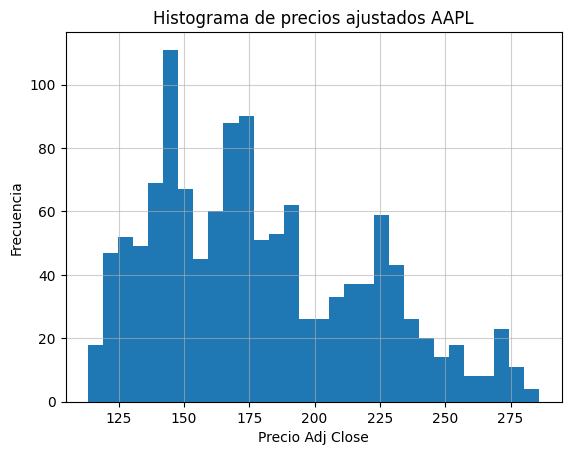

In [175]:
ticker = "AAPL"
bins = 30
prices = df.copy()

col = f"ADJ_CLOSE_{ticker}"
s = prices[col].dropna()

plt.figure()
plt.hist(s.values, bins = bins)
plt.title(f"Histograma de precios ajustados {ticker}")
plt.ylabel("Frecuencia")
plt.xlabel("Precio Adj Close")
plt.grid(alpha = 0.6)
plt.show()


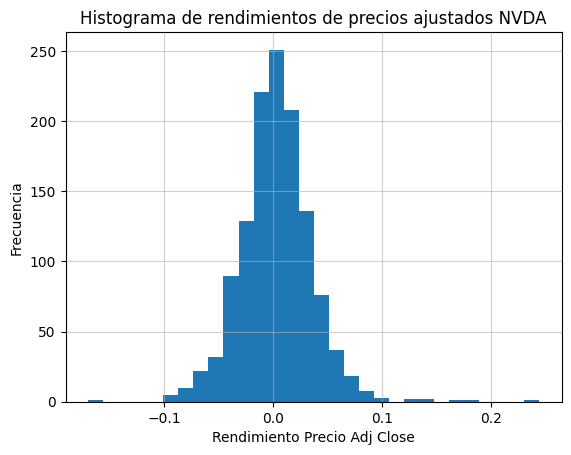

In [176]:
# hacer histograma de rendimientos
# valor(t)/valr(t-1) - 1

ticker = "NVDA"
bins = 30
prices = df.copy()

col = f"ADJ_CLOSE_{ticker}"
rend = prices[col].dropna()
rend = rend.pct_change()

plt.figure()
plt.hist(rend.values, bins = bins)
plt.title(f"Histograma de rendimientos de precios ajustados {ticker}")
plt.ylabel("Frecuencia")
plt.xlabel("Rendimiento Precio Adj Close")
plt.grid(alpha = 0.6)
plt.show()

In [177]:
# rend = prices[col].dropna()
# rendx = rend[1:].values / rend[:-1] - 1
# rendx

In [178]:
# Histogramas, Heatmap, Boxplot, time series,  time series con área bajo la vcurva, pie chart, barras, scatterplots, bubble plots, grouped stacked bars, waffle charts, violin, Table

### Heatmap

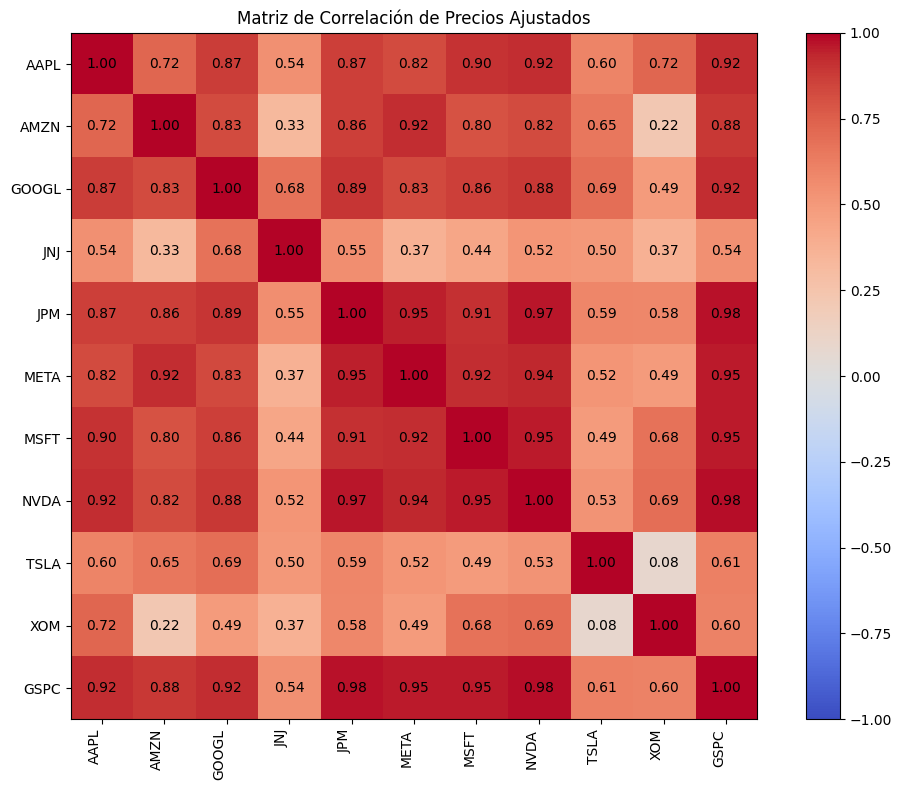

In [179]:
prices_2 = df.copy()
price_cols = [col for col in prices_2.columns if col.startswith("ADJ_CLOSE")]
prices_2 = prices_2[price_cols]

corr = prices_2.corr(method = "pearson")

labels = [c.replace("ADJ_CLOSE_", "") for c in corr.columns]
fig, ax = plt.subplots(figsize = (10,8))
im = ax.imshow(corr.values, cmap = "coolwarm", vmin = -1, vmax = 1)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation = 90, ha = "right")
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        text = ax.text(j, i, f"{corr.values[i,j]:.2f}", ha = "center", va = "center", color = "black")

ax.set_title("Matriz de Correlación de Precios Ajustados")
fig.tight_layout()
plt.colorbar(im, ax = ax)
plt.show()

In [180]:
# Tarea Obtener el heatmap de correlación de rendimientos

### Boxplot

C:\Users\hazae\AppData\Local\Temp\ipykernel_23668\3913437965.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(s.values, labels = [ticker], showfliers = True)


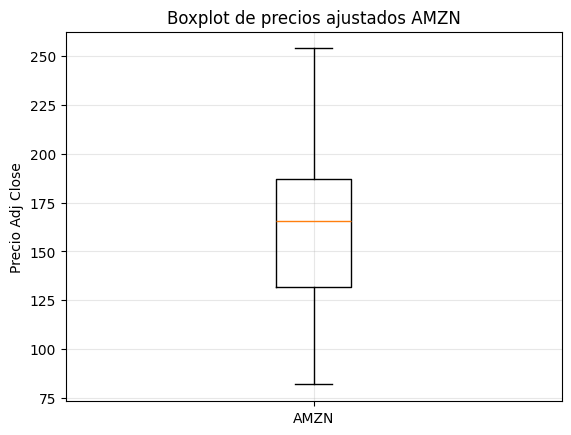

In [181]:
ticker = "AMZN"
prices = df.copy()

col = f"ADJ_CLOSE_{ticker}"
if col not in prices.columns:
    disponinles = ", ".join([c.replace("ADJ_CLOSE_", "") for c in prices.columns if c.startswith("ADJ_CLOSE_")])
    raise ValueError(f"Ticker {ticker} no encontrado. Disponibles: {disponinles}")

s = prices[col].dropna()

plt.figure()
plt.boxplot(s.values, labels = [ticker], showfliers = True)
plt.title(f"Boxplot de precios ajustados {ticker}")
plt.ylabel("Precio Adj Close")
plt.grid(True, alpha = 0.3)
plt.show()

# IQR = Percentil75 - Percentil25
# todo lo que esté por debajo de [Percentil25 - 1.5*IQR] o por encima de [Percentil75 + 1.5*IQR] se considera outlier

# skew
# kurtosis


In [182]:
# Tarea Obtener boxplot de rendimientos

### Serie de Tiempo

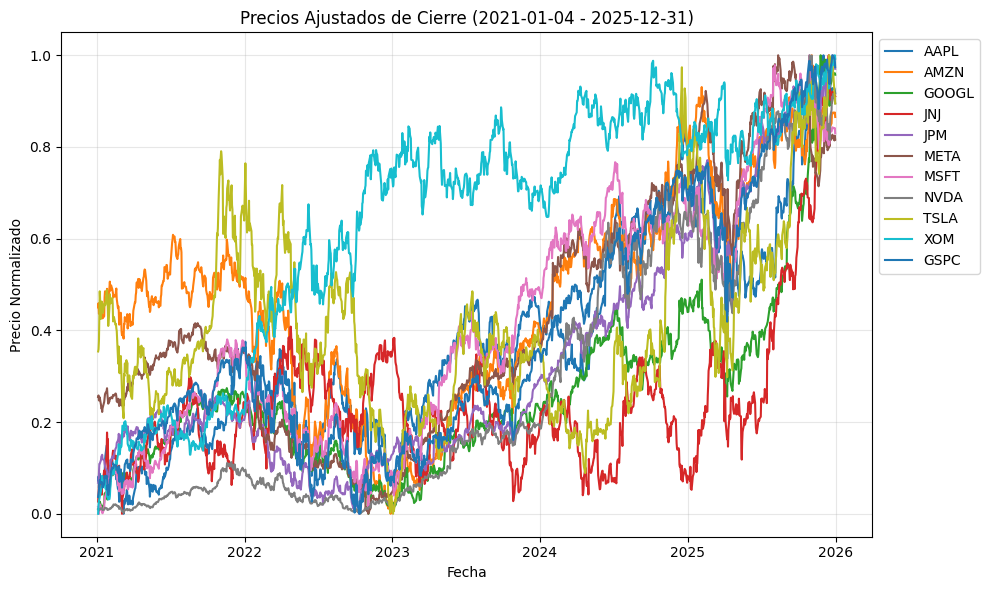

In [183]:
dfx = df.copy()
dfx["DATE"] = pd.to_datetime(dfx["Date"], errors = "coerce")
dfx = dfx.set_index("DATE")

normalize = True

Y = dfx[price_cols]
if normalize:
    for col in price_cols:
        s = Y[col]
        Y[col] = (s - s.min())/(s.max() - s.min())
        # if s.notna().any():
        #     base = s[s.notna()].iloc[0]
        #     Y[col] = (s / base)*100
        # else:
        #     Y[col] = np.nan

fig, ax = plt.subplots(figsize = (10,6))
for col in price_cols:
    series = Y[col]
    if series.notna().any():
        ax.plot(series.index, series.values, label = col.replace("ADJ_CLOSE_", ""))

locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

start = Y.index.min()
end = Y.index.max()

ax.set_title(f"Precios Ajustados de Cierre ({start.date()} - {end.date()})")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio" + (" Normalizado" if normalize else ""))
ax.grid(True, alpha = 0.3)
ax.legend(loc = "upper left", bbox_to_anchor = (1,1))
fig.tight_layout()
plt.show()

In [184]:
# Tarea: Evolución del valor de lals acciones respecto al año anterior y hace dos años

In [185]:
ticker = "AAPL"

### Time Series Con Área Bajo la Curva

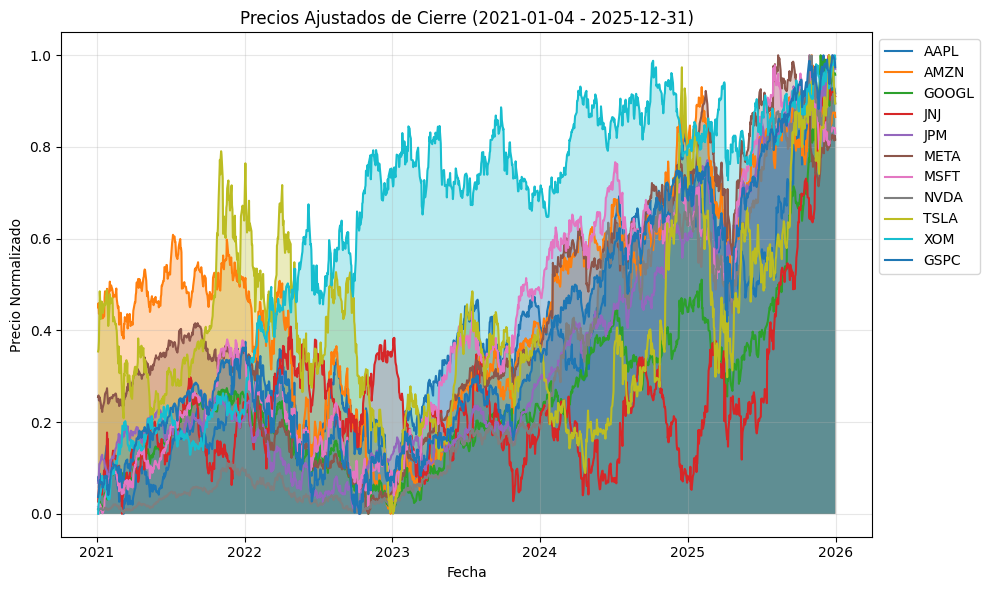

In [186]:
dfx = df.copy()
dfx["DATE"] = pd.to_datetime(dfx["Date"], errors = "coerce")
dfx = dfx.set_index("DATE")

normalize = True

Y = dfx[price_cols]
if normalize:
    for col in price_cols:
        s = Y[col]
        Y[col] = (s - s.min())/(s.max() - s.min())
        # if s.notna().any():
        #     base = s[s.notna()].iloc[0]
        #     Y[col] = (s / base)*100
        # else:
        #     Y[col] = np.nan

fig, ax = plt.subplots(figsize = (10,6))
for col in price_cols:
    series = Y[col]
    if series.notna().any():
        ax.plot(series.index, series.values, label = col.replace("ADJ_CLOSE_", ""))
        ax.fill_between(series.index, series.values, alpha = 0.3)

locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

start = Y.index.min()
end = Y.index.max()

ax.set_title(f"Precios Ajustados de Cierre ({start.date()} - {end.date()})")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio" + (" Normalizado" if normalize else ""))
ax.grid(True, alpha = 0.3)
ax.legend(loc = "upper left", bbox_to_anchor = (1,1))
fig.tight_layout()
plt.show()

In [187]:
# Tarea Evolución del valor de lals acciones respecto al año anterior y hace dos años con área bajo la curva

### Pie Chart

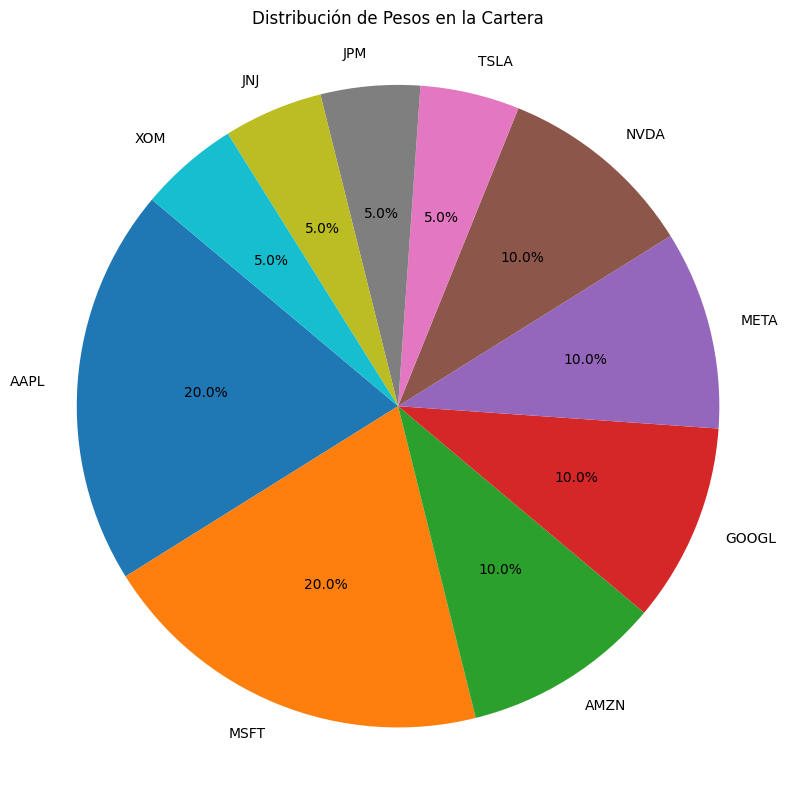

In [188]:
weights = {"AAPL": 0.2, "MSFT": 0.2, "AMZN": 0.1, "GOOGL": 0.1, "META": 0.1, "NVDA": 0.1, "TSLA": 0.05, "JPM": 0.05, "JNJ": 0.05, "XOM": 0.05}

labels = list(weights.keys())
values = list(weights.values())

plt.figure(figsize = (8,8))
wedges, texts, autotexts = plt.pie(values, labels = labels, autopct = "%1.1f%%", startangle = 140)
plt.title("Distribución de Pesos en la Cartera")
plt.axis("equal")
plt.tight_layout()
plt.show()


In [189]:
# Tarea: piechart con la proporción del rendimiento total aportada por acción

### Barchars

In [190]:
df["Date"]

0      2021-01-04
1      2021-01-05
2      2021-01-06
3      2021-01-07
4      2021-01-08
          ...    
1250   2025-12-24
1251   2025-12-26
1252   2025-12-29
1253   2025-12-30
1254   2025-12-31
Name: Date, Length: 1255, dtype: datetime64[s]

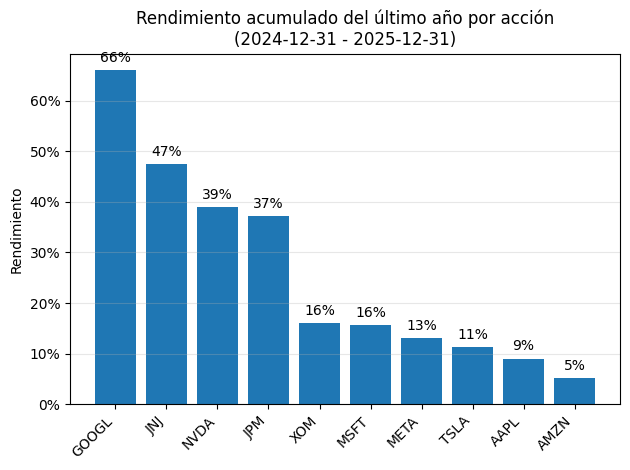

In [191]:
# rend acumulado del último año para cada acción

price_cols = [c for c in df.columns if "ADJ_CLOSE_" in c and c != "ADJ_CLOSE_GSPC"]

dfx = df.copy()
dfx["DATE"] = pd.to_datetime(dfx["Date"], errors = "coerce")
dfx = dfx.sort_values("DATE")

end = dfx["DATE"].max()
start = end - pd.DateOffset(years=1)

sub = dfx.loc[(dfx["DATE"] >= start) & (dfx["DATE"] <= end)]

rets = {}
for col in price_cols:
    s = sub[col].dropna()
    ticker = col.replace("ADJ_CLOSE_","")
    rets[ticker] = s.iloc[-1]/s.iloc[0] - 1

res = pd.Series(rets).sort_values(ascending = False)
tickers = res.index.to_list()
values = res.values

fig, ax = plt.subplots()
x = np.arange(len(tickers))
bars = ax.bar(x, values)

ax.set_xticks(x)
ax.set_xticklabels(tickers, rotation = 45, ha = "right")
ax.set_title(f"Rendimiento acumulado del último año por acción\n({start.date()} - {end.date()})")
ax.set_ylabel("Rendimiento")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(True, axis = "y", alpha = 0.3)

for xi, v in zip(x, values):
    ax.text(xi, v + (0.01 if v >= 0 else -0.01), f"{v:.0%}",
            ha = "center", va = "bottom" if v >= 0 else "top")

fig.tight_layout()
plt.show()

In [192]:
# Grafico de Barras con el rendimiento acumulado del portafolio para el ultimo año, mostrado por mes


### Grouped Barchar

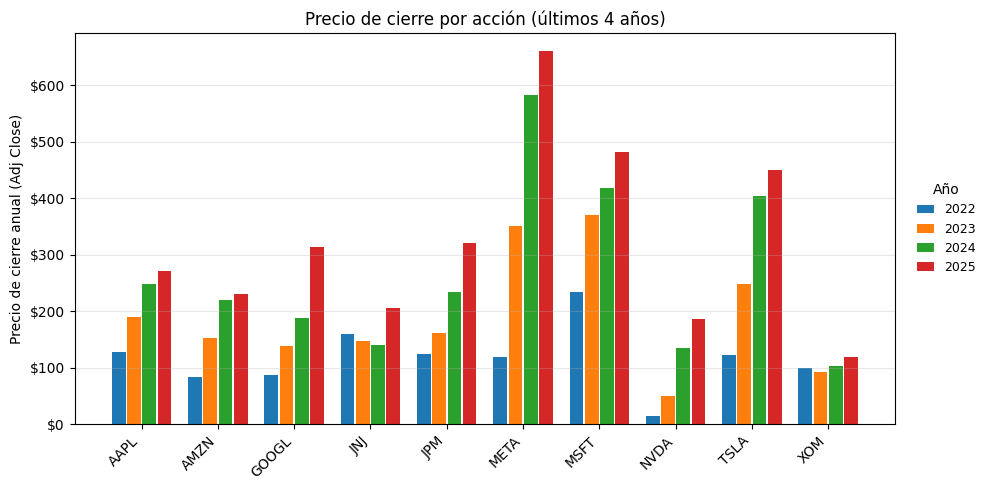

In [193]:
# rend acumulado del último año para cada acción

price_cols = [c for c in df.columns if "ADJ_CLOSE_" in c and c != "ADJ_CLOSE_GSPC"]

dx = df.copy()
dx["DATE"] = pd.to_datetime(dx["Date"], errors = "coerce")
dx = dx.sort_values("DATE")

# últimos 4 años disponibles en el DataFrame
years = sorted(dx["DATE"].dt.year.dropna().unique())[-4:]

tickers = [c.replace("ADJ_CLOSE_", "") for c in price_cols]

# matriz [ticker x año] con el ÚLTIMO precio disponible de cada año
mat = pd.DataFrame(index=tickers, columns=years, dtype=float)
for col in price_cols:
    tk = col.replace("ADJ_CLOSE_", "")
    tmp = dx[["DATE", col]].dropna()
    tmp["YEAR"] = tmp["DATE"].dt.year
    last_by_year = tmp.groupby("YEAR")[col].last()
    for y in years:
        mat.loc[tk, y] = last_by_year.get(y, np.nan)

# gráfico de barras agrupadas
x = np.arange(len(tickers))
n_years = len(years)
bar_w = 0.18
sep = 0.02

fig, ax = plt.subplots(figsize=(10, 5))
for i, y in enumerate(years):
    offset = (i - (n_years - 1) / 2) * (bar_w + sep)
    vals = mat[y].values
    ax.bar(x + offset, vals, width=bar_w, label=str(y))

ax.set_xticks(x)
ax.set_xticklabels(tickers, rotation=45, ha="right")
ax.set_ylabel("Precio de cierre anual (Adj Close)")
ax.set_title(f"Precio de cierre por acción (últimos {n_years} años)")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(title="Año", loc="center left", bbox_to_anchor=(1.02, 0.5), ncol=1, frameon=False,
    fontsize=9, title_fontsize=10, borderaxespad=0.0, handlelength=1.4 ,columnspacing=0.8)

# Opcional: formato moneda
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, pos: f"${v:,.0f}"))

fig.tight_layout()
plt.show()


In [194]:
mat

,2022,2023,2024,2025
AAPL,127.879318,190.550446,249.059464,271.605835
AMZN,84.000000,151.940002,219.389999,230.820007
GOOGL,87.506767,138.544922,188.428864,312.779816
JNJ,160.397446,146.637924,139.582520,205.855652
JPM,123.985634,161.958359,233.686676,320.773071
META,119.402992,351.203949,583.170166,659.525330
MSFT,233.686661,369.671875,417.460602,482.518677
NVDA,14.598595,49.491749,134.246017,186.489914
TSLA,123.180000,248.479996,403.839996,449.720001
XOM,98.830093,92.641808,103.074776,119.543198


In [195]:
# Tarea: rendimiento maximi, minimo y promedio por acción

### Waffle Plot

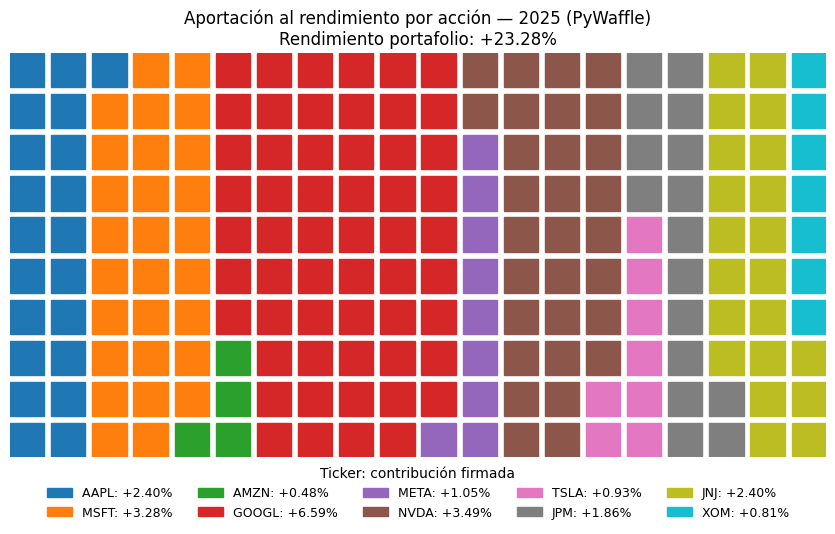

In [196]:
# Diccionario con los pesos objetivo del portafolio.
# Cada clave es un ticker y cada valor es su peso dentro del portafolio.
weights = {
    "AAPL": 0.2,
    "MSFT": 0.2,
    "AMZN": 0.1,
    "GOOGL": 0.1,
    "META": 0.1,
    "NVDA": 0.1,
    "TSLA": 0.05,
    "JPM": 0.05,
    "JNJ": 0.05,
    "XOM": 0.05
}

# Diccionario que asigna un color a cada ticker.
# Esto se usa después para colorear cada bloque del waffle chart.
TICKER_COLORS = {
    "AAPL": "#1f77b4",
    "MSFT": "#ff7f0e",
    "AMZN": "#2ca02c",
    "GOOGL": "#d62728",
    "META": "#9467bd",
    "NVDA": "#8c564b",
    "TSLA": "#e377c2",
    "JPM":  "#7f7f7f",
    "JNJ":  "#bcbd22",
    "XOM":  "#17becf",
}

# Número total de cuadros que tendrá el waffle.
# 200 significa que el gráfico se repartirá en 200 bloques.
TOTAL_TILES = 200  # tamaño del waffle (10x10 visualmente distribuido en 200 bloques)

# Se crea una copia del DataFrame original para no modificar df directamente.
prices = df.copy()

# Convierte la columna "Date" a formato datetime.
# errors="coerce" hace que valores inválidos se conviertan en NaT.
prices["DATE"] = pd.to_datetime(prices["Date"], errors="coerce")

# Ordena el DataFrame por fecha ascendente.
# Esto es importante para que el primer valor sea el inicial del año
# y el último valor sea el más reciente dentro del periodo.
prices = prices.sort_values("DATE")


# =========================
# FILTRO DE FECHAS: AÑO 2025
# =========================

# Define la fecha inicial de la ventana de análisis.
start_2025 = pd.Timestamp("2025-01-01")

# Define la fecha final de la ventana de análisis.
end_2025 = pd.Timestamp("2025-12-31")

# Crea una máscara booleana:
# True para las filas cuya fecha esté entre inicio y fin de 2025.
mask_2025 = (prices["DATE"] >= start_2025) & (prices["DATE"] <= end_2025)

# Aplica la máscara al DataFrame para quedarse solo con datos de 2025.
# reset_index(drop=True) reinicia el índice desde 0 y elimina el índice anterior.
p25 = prices.loc[mask_2025].reset_index(drop=True)


# =======================================
# CÁLCULO DE RETORNOS POR ACCIÓN EN 2025
# =======================================

# Diccionario donde se guardará el retorno YTD 2025 de cada ticker.
rets_2025 = {}

# Lista para guardar únicamente los tickers que sí estén presentes y utilizables.
present = []

# Recorre cada ticker definido en el diccionario de pesos.
for tk in weights.keys():
    # Construye dinámicamente el nombre de la columna esperada en el DataFrame.
    # Ejemplo: para "AAPL" será "ADJ_CLOSE_AAPL".
    col = f"ADJ_CLOSE_{tk}"
    
    # Toma la serie de precios ajustados de ese ticker dentro de 2025,
    # eliminando valores nulos.
    s = p25[col].dropna()
    
    # Calcula el retorno del periodo:
    # (precio final / precio inicial) - 1
    # Esto da el rendimiento porcentual acumulado del año.
    r = s.iloc[-1] / s.iloc[0] - 1.0
    
    # Guarda el retorno como float en el diccionario.
    rets_2025[tk] = float(r)
    
    # Guarda el ticker en la lista de presentes.
    # Esto sirve por si más adelante algún ticker faltara.
    present.append(tk)


# ==================================================
# NORMALIZACIÓN DE PESOS SI FALTA ALGÚN TICKER
# ==================================================

# Crea un arreglo NumPy con los pesos de los tickers realmente presentes.
w = np.array([weights[tk] for tk in present], dtype=float)

# Re-normaliza los pesos para que sumen 1.
# Esto es útil si alguno de los tickers originalmente definidos no estuvo disponible.
w = w / w.sum()


# ======================================================
# CONTRIBUCIÓN DE CADA ACCIÓN AL RENDIMIENTO DEL PORTAFOLIO
# ======================================================

# Crea un arreglo con los retornos de los tickers presentes.
r = np.array([rets_2025[tk] for tk in present], dtype=float)

# Calcula la contribución de cada activo al rendimiento total:
# contribución_i = peso_i * retorno_i
# El resultado se guarda en un diccionario:
# {"AAPL": ..., "MSFT": ..., etc.}
contrib = dict(zip(present, w * r))

# Suma todas las contribuciones para obtener el rendimiento total del portafolio en 2025.
port_ret_2025 = float(sum(contrib.values()))

# Convierte las contribuciones a magnitudes absolutas.
# Se usa valor absoluto porque en el waffle el tamaño del bloque
# representa magnitud de aportación, no signo.
magnitudes = np.abs(np.array([contrib[tk] for tk in present], dtype=float))

# Suma total de las magnitudes absolutas.
# Esto servirá para repartir los bloques proporcionalmente.
total_mag = magnitudes.sum()


# ======================================================
# CONVERSIÓN DE CONTRIBUCIONES A NÚMERO DE BLOQUES (TILES)
# ======================================================

# Calcula cuántos bloques le corresponderían a cada ticker en proporción
# a su magnitud de contribución.
proportions = magnitudes / total_mag * TOTAL_TILES

# Toma la parte entera hacia abajo de cada proporción.
# Ejemplo: si algo da 12.8, aquí se queda en 12.
tiles_floor = np.floor(proportions).astype(int)

# Calcula la parte decimal sobrante de cada ticker.
# Ejemplo: si era 12.8, el residuo es 0.8.
remainders = proportions - tiles_floor

# Calcula cuántos bloques faltan por asignar para completar TOTAL_TILES.
# Esto pasa porque al redondear hacia abajo, normalmente sobran algunos bloques sin asignar.
missing = int(TOTAL_TILES - tiles_floor.sum())

# Ordena los índices de mayor a menor según el residuo decimal.
# Así, los bloques sobrantes se asignan primero a quienes más "perdieron" al redondear.
order = np.argsort(-remainders)

# Copia del arreglo base de bloques.
tiles = tiles_floor.copy()

# Reparte los bloques faltantes uno por uno a los mayores residuos.
for i in range(missing):
    tiles[order[i]] += 1


# ============================================
# FILTRADO FINAL DE TICKERS CON 0 BLOQUES
# ============================================

# Máscara booleana: True para tickers que sí recibieron al menos 1 bloque.
mask_pos = tiles > 0

# Convierte la lista de tickers presentes a arreglo y filtra solo los que tienen bloques > 0.
present_arr = np.array(present)[mask_pos]

# Filtra también el arreglo de bloques.
tiles = tiles[mask_pos]

# Genera la lista de colores correspondiente a los tickers filtrados.
# Si algún ticker no tiene color definido, usa gris "#999999".
colors = [TICKER_COLORS.get(tk, "#999999") for tk in present_arr]

# Genera las etiquetas para la leyenda.
# Ejemplo: "AAPL: +2.34%" o "TSLA: -0.85%"
labels = [f"{tk}: {contrib[tk]:+,.2%}" for tk in present_arr]

# Construye el diccionario final que PyWaffle necesita:
# {etiqueta: número_de_bloques}
values_dict = {lab: int(n) for lab, n in zip(labels, tiles)}


# =========================
# CREACIÓN DEL WAFFLE CHART
# =========================

# Crea la figura usando PyWaffle.
fig = plt.figure(
    FigureClass=Waffle,              # Indica que la figura será tipo waffle
    rows=10,                         # Número de filas del waffle
    values=values_dict,              # Cantidad de bloques por etiqueta
    colors=colors,                   # Colores por ticker
    block_arranging_style="snake",   # Orden tipo serpiente al acomodar bloques
    starting_location="NW",          # Empieza en la esquina noroeste (arriba izquierda)
    figsize=(9, 6),                  # Tamaño de la figura
    legend={                         # Configuración de la leyenda
        "loc": "lower center",       # Ubicación de la leyenda
        "bbox_to_anchor": (0.5, -0.18),  # Ajuste fino de posición
        "ncol": 5,                   # Número de columnas en la leyenda
        "frameon": False,            # Sin borde alrededor de la leyenda
        "title": "Ticker: contribución firmada",  # Título de la leyenda
        "fontsize": 9                # Tamaño de letra
    },
)

# Agrega el título principal del gráfico.
# Incluye también el rendimiento total del portafolio en 2025.
plt.title(
    "Aportación al rendimiento por acción — 2025 (PyWaffle)\n"
    f"Rendimiento portafolio: {port_ret_2025:+.2%}"
)

# Ajusta el margen inferior para que la leyenda no quede encimada o cortada.
plt.subplots_adjust(bottom=0.30)

# Muestra el gráfico en pantalla.
plt.show()

### Stacked Barchar

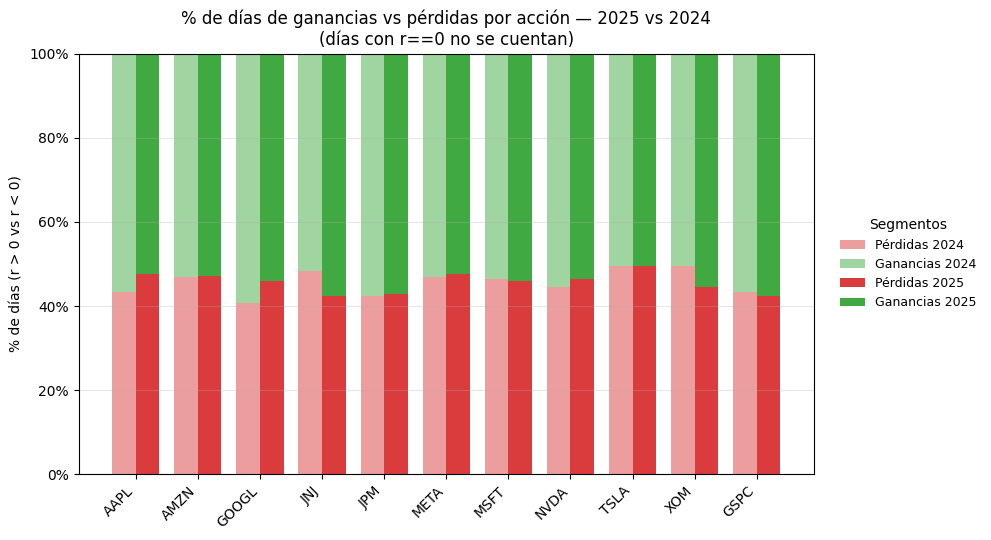

In [197]:
# Crea una lista con todas las columnas del DataFrame cuyo nombre empieza con "ADJ_CLOSE_".
# Es decir, busca las columnas de precios ajustados de cada acción.
price_cols = [c for c in df.columns if c.startswith("ADJ_CLOSE_")]


# Hace una copia del DataFrame original para no modificar df directamente.
dx = df.copy()

# Convierte la columna "Date" a formato fecha.
# Si algún valor no se puede convertir, lo transforma en NaT (fecha nula).
dx["DATE"] = pd.to_datetime(dx["Date"], errors="coerce")

# Ordena el DataFrame cronológicamente por fecha.
# Esto es importante antes de calcular retornos diarios con pct_change().
dx = dx.sort_values("DATE")


# Obtiene la fecha más reciente disponible en el DataFrame.
end_date = dx["DATE"].max()

# Extrae el año actual a partir de la fecha máxima.
yr_curr = int(end_date.year)

# Define el año previo como el año actual menos 1.
yr_prev = yr_curr - 1


# Crea un nuevo DataFrame con la columna de fecha y las columnas de precios ajustados.
rets = dx[["DATE"] + price_cols].copy()

# Convierte precios en retornos diarios porcentuales usando pct_change().
# Ejemplo: si ayer valía 100 y hoy 102, el retorno será 0.02.
rets[price_cols] = rets[price_cols].pct_change()

# Genera la lista de tickers quitando el prefijo "ADJ_CLOSE_" de cada nombre de columna.
# Ejemplo: "ADJ_CLOSE_AAPL" -> "AAPL"
tickers = [c.replace("ADJ_CLOSE_", "") for c in price_cols]

# Inicializa listas vacías para guardar:
# - días de ganancia del año actual
# - días de pérdida del año actual
# - días de ganancia del año previo
# - días de pérdida del año previo
gain_curr, loss_curr, gain_prev, loss_prev = [], [], [], []


# Recorre cada columna de precios ajustados (cada acción).
for col in price_cols:
    
    # Toma solo la fecha y la columna actual, y elimina filas con valores nulos.
    # Esto evita problemas por el primer NaN generado por pct_change() o datos faltantes.
    r = rets[["DATE", col]].dropna()
    
    # Filtra los retornos de la acción para el año actual.
    rc = r[r["DATE"].dt.year == yr_curr][col]
    
    # Filtra los retornos de la acción para el año anterior.
    rp = r[r["DATE"].dt.year == yr_prev][col]

    # Cuenta cuántos días del año actual tuvieron retorno positivo (r > 0)
    # y lo guarda como entero en la lista gain_curr.
    gain_curr.append(int((rc > 0).sum()))

    # Cuenta cuántos días del año actual tuvieron retorno negativo (r < 0)
    # y lo guarda en loss_curr.
    loss_curr.append(int((rc < 0).sum()))

    # Cuenta cuántos días del año previo tuvieron retorno positivo.
    gain_prev.append(int((rp > 0).sum()))

    # Cuenta cuántos días del año previo tuvieron retorno negativo.
    loss_prev.append(int((rp < 0).sum()))


# Convierte las listas a arreglos NumPy de enteros.
# Esto facilita operaciones vectorizadas posteriores.
gain_curr = np.array(gain_curr, dtype=int)
loss_curr = np.array(loss_curr, dtype=int)
gain_prev = np.array(gain_prev, dtype=int)
loss_prev = np.array(loss_prev, dtype=int)


# Calcula el total de días contabilizados por acción en cada año:
# total = días con ganancia + días con pérdida
# Los días con retorno exactamente igual a 0 no se incluyen.
tot_curr = gain_curr + loss_curr
tot_prev = gain_prev + loss_prev


# Evita división entre cero:
# si alguna acción no tuvo días válidos en un año, el total sería 0,
# así que se reemplaza por 1 solo para que no falle la división.
# Esto hace que el porcentaje quede en 0/1 = 0 en esos casos.
tot_curr = np.where(tot_curr == 0, 1, tot_curr)
tot_prev = np.where(tot_prev == 0, 1, tot_prev)

# Calcula el porcentaje de días de ganancia en el año actual.
gain_curr_pct = gain_curr / tot_curr

# Calcula el porcentaje de días de pérdida en el año actual.
loss_curr_pct = loss_curr / tot_curr

# Calcula el porcentaje de días de ganancia en el año previo.
gain_prev_pct = gain_prev / tot_prev

# Calcula el porcentaje de días de pérdida en el año previo.
loss_prev_pct = loss_prev / tot_prev


# ==========================================
# CONSTRUCCIÓN DEL GRÁFICO DE BARRAS APILADAS
# ==========================================

# Crea un arreglo de posiciones para el eje X:
# una posición por ticker.
x = np.arange(len(tickers))

# Define el ancho de cada barra.
w = 0.38

# Crea la figura y los ejes del gráfico.
fig, ax = plt.subplots(figsize=(10, 5.5))

# Dibuja las barras del año previo para pérdidas.
# Se colocan a la izquierda de cada ticker con x - w/2.
# alpha=0.45 las hace más transparentes para diferenciarlas del año actual.
ax.bar(
    x - w/2,
    loss_prev_pct,
    width=w,
    color="#d62728",
    alpha=0.45,
    label=f"Pérdidas {yr_prev}"
)

# Dibuja las barras del año previo para ganancias.
# Se apilan arriba de las pérdidas usando bottom=loss_prev_pct.
ax.bar(
    x - w/2,
    gain_prev_pct,
    width=w,
    bottom=loss_prev_pct,
    color="#2ca02c",
    alpha=0.45,
    label=f"Ganancias {yr_prev}"
)

# Dibuja las barras del año actual para pérdidas.
# Se colocan a la derecha de cada ticker con x + w/2.
# alpha=0.9 las hace más sólidas/visibles.
ax.bar(
    x + w/2,
    loss_curr_pct,
    width=w,
    color="#d62728",
    alpha=0.9,
    label=f"Pérdidas {yr_curr}"
)

# Dibuja las barras del año actual para ganancias,
# apiladas arriba de las pérdidas del mismo año.
ax.bar(
    x + w/2,
    gain_curr_pct,
    width=w,
    bottom=loss_curr_pct,
    color="#2ca02c",
    alpha=0.9,
    label=f"Ganancias {yr_curr}"
)


# Define las posiciones del eje X.
ax.set_xticks(x)

# Asigna como etiquetas del eje X los tickers.
# rotation=45 inclina los nombres para que no se encimen.
# ha="right" alinea el texto hacia la derecha.
ax.set_xticklabels(tickers, rotation=45, ha="right")

# Etiqueta del eje Y.
ax.set_ylabel("% de días (r > 0 vs r < 0)")

# Título del gráfico.
# Indica que se comparan los porcentajes de días con ganancias vs pérdidas
# entre el año actual y el previo.
ax.set_title(
    f"% de días de ganancias vs pérdidas por acción — {yr_curr} vs {yr_prev}\n"
    "(días con r==0 no se cuentan)"
)

# Formatea el eje Y como porcentaje, asumiendo que los valores van de 0 a 1.
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Fija el rango del eje Y entre 0 y 1 (0% a 100%).
ax.set_ylim(0, 1)

# Agrega una cuadrícula horizontal tenue para facilitar lectura.
ax.grid(True, axis="y", alpha=0.3)


# =========================
# CONFIGURACIÓN DE LA LEYENDA
# =========================

ax.legend(
    title="Segmentos",           # título de la leyenda
    loc="center left",           # ancla de la leyenda
    bbox_to_anchor=(1.02, 0.5),  # la mueve fuera del gráfico a la derecha
    ncol=1,                      # una sola columna
    frameon=False,               # sin cuadro alrededor
    fontsize=9,                  # tamaño de texto
    title_fontsize=10,           # tamaño del título de la leyenda
)

# Deja espacio extra a la derecha para que la leyenda no se corte.
plt.subplots_adjust(right=0.80)

# Ajusta automáticamente espacios internos de la figura.
fig.tight_layout()

# Muestra el gráfico.
plt.show()

### Bubblecharts

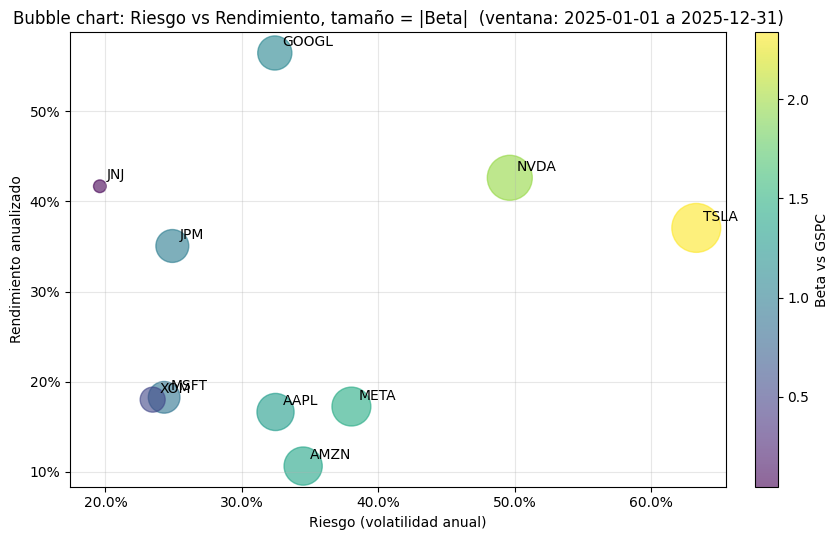

In [198]:
# Crea una lista con las columnas que contienen "ADJ_CLOSE_"
# pero excluye explícitamente la columna del mercado general "ADJ_CLOSE_GSPC".
# Es decir, aquí se quedan solo las acciones individuales.
price_cols = [c for c in df.columns if "ADJ_CLOSE_" in c and c != "ADJ_CLOSE_GSPC"]


# Hace una copia del DataFrame original para no modificar df directamente.
dx = df.copy()

# Convierte la columna "Date" a tipo fecha.
# Si encuentra valores inválidos, los convierte en NaT.
dx["DATE"] = pd.to_datetime(dx["Date"], errors="coerce")

# Ordena el DataFrame por fecha en orden ascendente.
# Esto es importante para trabajar correctamente con series de tiempo.
dx = dx.sort_values("DATE")


# Obtiene la fecha más reciente disponible en los datos.
end = dx["DATE"].max()

# Define la fecha de inicio como 1 año antes de la fecha final,
# más 1 día para construir una ventana de aproximadamente un año.
start = end - pd.DateOffset(years=1) + pd.DateOffset(days=1)


# Filtra el DataFrame para quedarse solo con:
# - las fechas dentro de la ventana de 1 año
# - las columnas de precios de las acciones
# - la columna del índice de mercado GSPC
sub = dx.loc[
    (dx["DATE"] > start) & (dx["DATE"] <= end),
    ["DATE"] + price_cols + ["ADJ_CLOSE_GSPC"]
]

# Elimina filas donde todas las columnas sean nulas.
# Si una fila completa no tiene información útil, se descarta.
sub = sub.dropna(how="all")


# Convierte los precios en retornos porcentuales diarios.
# Primero pone la fecha como índice.
# Luego usa pct_change() para obtener rendimientos diarios.
# Finalmente elimina filas con cualquier NaN.
R = sub.set_index("DATE").pct_change().dropna(how="any")


# Guarda el nombre de la columna del mercado.
# Esta será la referencia para calcular la beta.
mkt_col = "ADJ_CLOSE_GSPC"

# Crea una lista de tickers quitando el prefijo "ADJ_CLOSE_".
# Ejemplo: "ADJ_CLOSE_AAPL" -> "AAPL"
tickers = [c.replace("ADJ_CLOSE_", "") for c in price_cols]


# Lista vacía donde se irán guardando las métricas calculadas por acción.
rows = []


# Recorre cada columna de precios de acción.
for col in price_cols:
    
    # Toma únicamente dos columnas:
    # - la acción actual
    # - el mercado (GSPC)
    # y elimina filas con valores nulos.
    pair = R[[col, mkt_col]].dropna()

    # Calcula el rendimiento promedio diario de la acción y lo anualiza.
    # Multiplica por 252 porque suele asumirse que hay 252 días bursátiles al año.
    mu_ann = pair[col].mean() * 252.0

    # Calcula la volatilidad diaria de la acción y la anualiza.
    # Se multiplica por sqrt(252) para anualizar.
    sig_ann = pair[col].std() * np.sqrt(252.0)

    # Calcula la matriz de covarianza entre la acción y el mercado.
    cov = pair.cov()

    # Calcula la beta de la acción respecto al mercado:
    # beta = cov(acción, mercado) / var(mercado)
    # Esto mide qué tan sensible es la acción a los movimientos del mercado.
    beta = cov.loc[col, mkt_col] / cov.loc[mkt_col, mkt_col]  # beta vs mercado

    # Guarda los resultados en forma de diccionario.
    rows.append({
        "TICKER": col.replace("ADJ_CLOSE_", ""),
        "MU": mu_ann,
        "SIGMA": sig_ann,
        "BETA": beta
    })


# Convierte la lista de diccionarios en un DataFrame.
# Cada fila representa una acción y sus métricas.
metrics = pd.DataFrame(rows)


# Obtiene el valor absoluto de las betas.
# Se usa valor absoluto porque el tamaño de la burbuja depende de la magnitud de la beta,
# no de su signo.
abs_beta = metrics["BETA"].abs().values

# Calcula la mediana de las betas absolutas.
# Esto sirve como referencia para escalar tamaños de las burbujas.
# Si no hubiera valores finitos, usa 1.0 por seguridad.
median_abs = np.median(abs_beta) if np.isfinite(abs_beta).any() else 1.0

# Factor de escala base para el tamaño de las burbujas.
scale = 600.0

# Calcula el tamaño de cada burbuja.
# - Si una beta es igual a la mediana, tendrá aproximadamente tamaño "scale"
# - Se suma 60 para garantizar que ninguna burbuja quede demasiado pequeña.
sizes = scale * (abs_beta / (median_abs if median_abs > 0 else 1.0)) + 60.0  # tamaño mínimo


# Crea la figura y los ejes del gráfico.
fig, ax = plt.subplots(figsize=(8.5, 5.5))

# Dibuja un scatter plot tipo bubble chart:
# - eje X: volatilidad anual (SIGMA)
# - eje Y: rendimiento anualizado (MU)
# - tamaño: magnitud de la beta
# - color: valor de la beta
# - alpha: transparencia
sc = ax.scatter(
    metrics["SIGMA"],
    metrics["MU"],
    s=sizes,
    c=metrics["BETA"],
    alpha=0.6
)


# Recorre cada fila del DataFrame de métricas para etiquetar cada punto.
for _, r in metrics.iterrows():
    # Coloca el ticker al lado de su burbuja.
    # xytext=(5,5) desplaza la etiqueta ligeramente para que no se monte exactamente sobre el punto.
    ax.annotate(
        r["TICKER"],
        (r["SIGMA"], r["MU"]),
        xytext=(5, 5),
        textcoords="offset points"
    )


# Etiqueta del eje X.
ax.set_xlabel("Riesgo (volatilidad anual)")

# Etiqueta del eje Y.
ax.set_ylabel("Rendimiento anualizado")

# Formatea el eje X como porcentaje.
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Formatea el eje Y como porcentaje.
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Agrega una cuadrícula tenue para facilitar la lectura.
ax.grid(True, alpha=0.3)


# Crea una barra de color para interpretar el valor de la beta.
cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

# Etiqueta de la barra de color.
cbar.set_label("Beta vs GSPC")


# Título del gráfico.
# Indica qué representa cada eje y que el tamaño depende de |Beta|.
# También muestra la ventana de fechas analizada.
ax.set_title(
    f"Bubble chart: Riesgo vs Rendimiento, tamaño = |Beta|  (ventana: {start.date()} a {end.date()})"
)

# Ajusta automáticamente los espacios para que nada se encime o se recorte.
fig.tight_layout()

# Muestra el gráfico.
plt.show()

In [199]:
metrics

,TICKER,MU,SIGMA,BETA
0,AAPL,0.166449,0.324641,1.298115
1,AMZN,0.106437,0.344892,1.380444
2,GOOGL,0.564754,0.324116,1.078928
3,JNJ,0.416906,0.195867,0.047024
4,JPM,0.350619,0.249001,0.992836
5,META,0.172472,0.380266,1.436324
6,MSFT,0.182690,0.242987,0.911028
7,NVDA,0.426287,0.496366,1.961928
8,TSLA,0.370687,0.633076,2.337109
9,XOM,0.180130,0.234584,0.523618


### Scatterplot

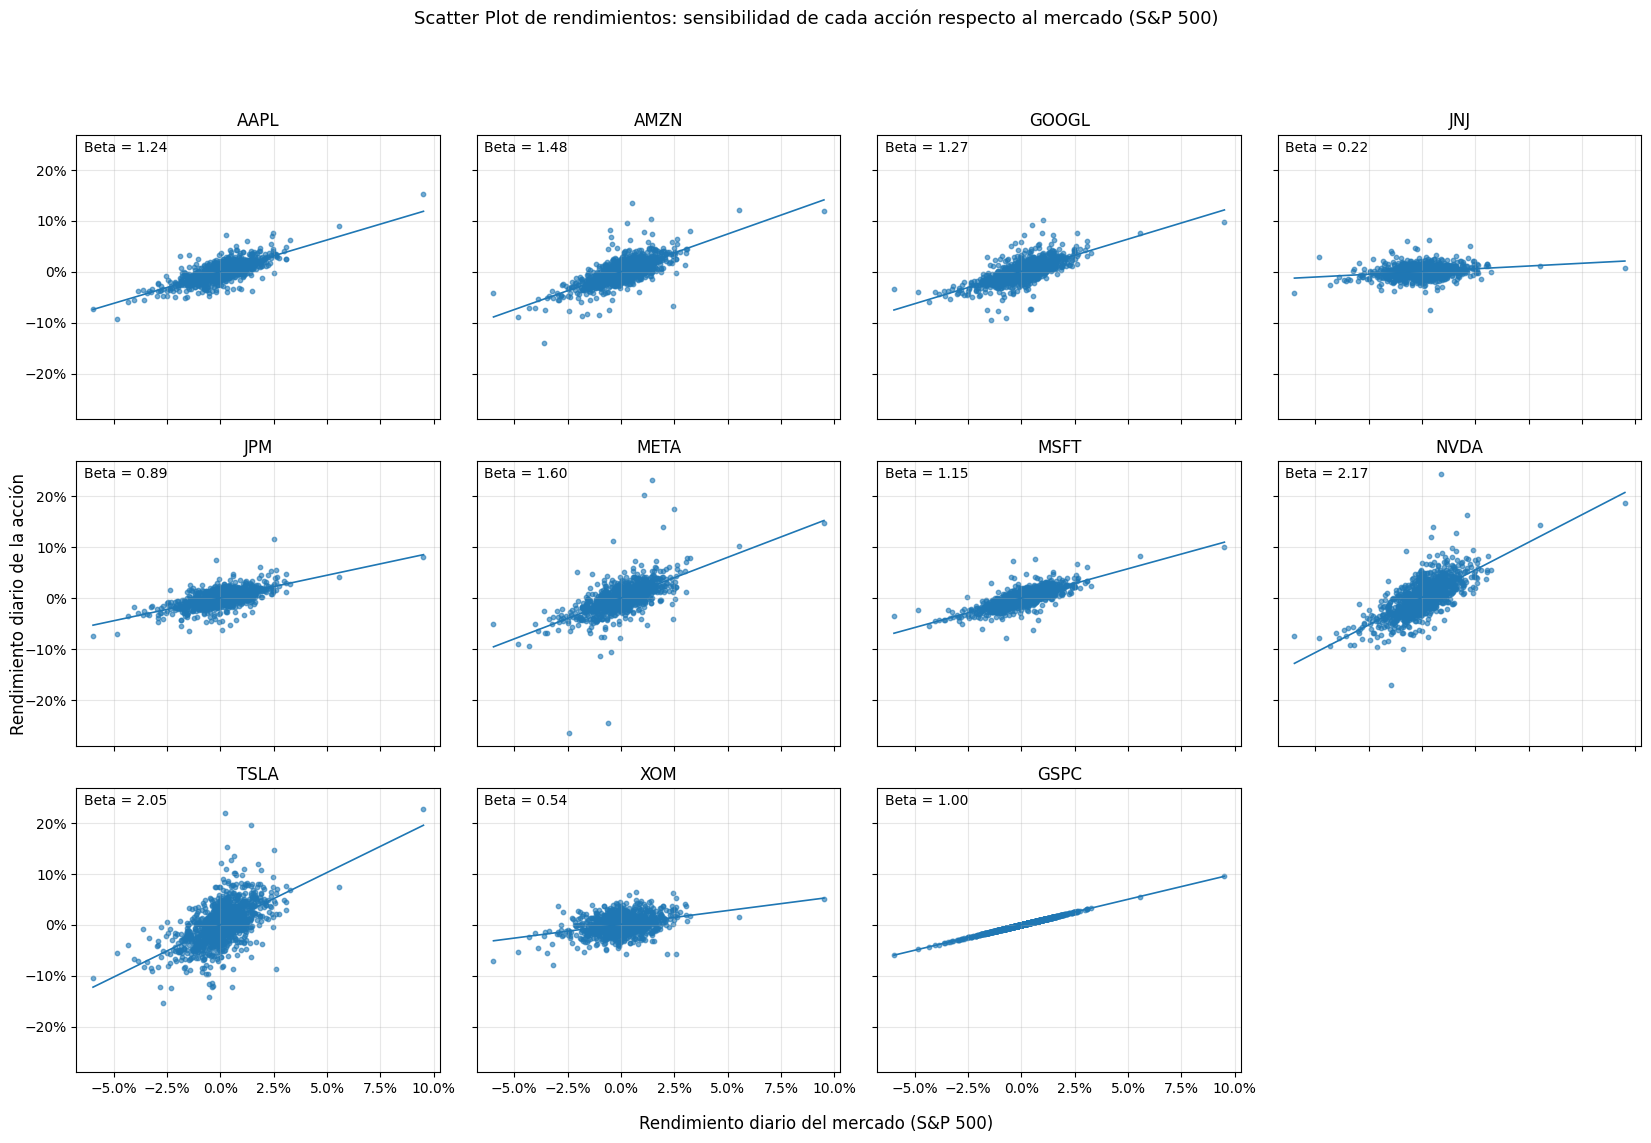

In [200]:
price_cols = [c for c in df.columns if c.startswith("ADJ_CLOSE_")]
dfx12 = df.copy()

dfx12["Date"] = pd.to_datetime(dfx12["Date"], errors = "coerce")
dfx12 = dfx12.sort_values("Date")

start = dfx12["Date"].min().normalize()
end = dfx12["Date"].max().normalize()

rets = dfx12.copy()
rets[price_cols] = rets[price_cols].pct_change()
rets = rets.dropna()

mkt = rets["ADJ_CLOSE_GSPC"]

tickers = [c.replace("ADJ_CLOSE_","") for c in price_cols]
n = len(tickers)
ncols = 4 if n>= 8 else 3
nrows = math.ceil(n/ncols)

fig, axes = plt.subplots(nrows, ncols, figsize =(4.2*ncols, 3.6*nrows), sharex = True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for i, col in enumerate(price_cols):
    ax = axes[i]
    y = rets[col]
    x = mkt
    xant = x.copy()
    x = x[xant.notna() & y.notna()]
    y = y[xant.notna() & y.notna()]
    ax.scatter(x, y, s=10, alpha = 0.6)

    slope, intercept = np.polyfit(x.values, y.values, deg = 1)
    xline = np.linspace(x.min(), x.max(), 100)
    ax.plot(xline,slope * xline + intercept, linewidth = 1.2)
    yhat = slope * xline + intercept
    ax.text(0.02, 0.98, f"Beta = {slope:.2f}", transform = ax.transAxes, va = "top", ha = "left")
    ax.set_title(col.replace("ADJ_CLOSE_",""))

    for k in range(n, len(axes)):
        axes[k].set_visible(False)

    for ax in axes[:n]:
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        ax.grid(True, alpha = 0.3)

fig.suptitle("Scatter Plot de rendimientos: sensibilidad de cada acción respecto al mercado (S&P 500)", y=1.05, fontsize=13)
fig.supxlabel("Rendimiento diario del mercado (S&P 500)")
fig.supylabel("Rendimiento diario de la acción")
fig.tight_layout()
plt.show()


In [201]:
### remover s&p 500 de mi análisis de sensibilidad

### Table

In [210]:
rows = []
year_start = pd.Timestamp(as_of.year,1,1)
one_year_ago = as_of - pd.DateOffset(years = 1)

for col in price_cols:
    ticker = col.replace("ADJ_CLOSE_","")
    s = px[col].dropna()

    rows.append({"Ticker":ticker, "Last Price":s.iloc[-1] if not s.empty else np.nan,
                 "Last Week": period_return(s,periods=5), "Last Month": period_return(s, periods=21),
                 "YTD": period_return(s, start_date=year_start), "YoY": period_return(s, start_date=one_year_ago)})
    
ret_table = pd.DataFrame(rows)
ret_table = ret_table.sort_values(by=["YTD", "Last Month", "Last Week"],ascending=False).reset_index(drop=True)
ret_table.insert(0, "Rank", np.arange(1, len(ret_table) + 1))


def winners_losers_style(col):
    vals = pd.to_numeric(col, errors="coerce").values

    has_pos = np.any(vals > 0)
    has_neg = np.any(vals < 0)

    pos_max = np.nanmax(np.where(vals > 0, vals, np.nan)) if has_pos else np.nan
    neg_min = np.nanmin(np.where(vals < 0, vals, np.nan)) if has_neg else np.nan

    styles = []
    for v in vals:
        if pd.isna(v):
            styles.append("background-color: #f5f5f5; color: #999999;")
        
        elif v > 0:
            intensity = 0.20 + 0.75 * (v / pos_max if pos_max > 0 else 0)
            styles.append(f"background-color: rgba(46, 125, 50, {intensity:.2f}); "
                          "color: white; font-weight: 600;")

        elif v < 0:
            intensity = 0.20 + 0.75 * (abs(v) / abs(neg_min) if neg_min < 0 else 0)
            styles.append(f"background-color: rgba(198, 40, 40, {intensity:.2f}); "
                          "color: white; font-weight: 600;")

        else:
            styles.append("background-color: #eeeeee; color: black; font-weight: 600;")

    return styles
    


styled_ret_table = (ret_table.style
                    .format({"Last Price": "{:,.0f}",
                             "Last Week": "{:+.2%}",
                             "Last Month": "{:+.2%}",
                             "YTD": "{:+.2%}",
                             "YoY": "{:+.2%}"})
                    .apply(winners_losers_style, subset=["Last Week"])
                    .apply(winners_losers_style, subset=["Last Month"])
                    .apply(winners_losers_style, subset=["YTD"])
                    .apply(winners_losers_style, subset=["YoY"])
                    .set_properties(subset=["Ticker"], **{"font-weight": "bold"})
                    .set_properties(subset=["Rank"], **{"text-align": "center"})
                    .set_properties(**{"border": "1px solid #d9d9d9",
                                       "padding": "6px",
                                       "text-align": "center"})

                    .set_table_styles([{"selector": "th", "props": [("background-color", "#111111"),
                                                                    ("color", "white"),
                                                                    ("font-weight", "bold"),
                                                                    ("text-align", "center")]},
                                        {"selector": "caption", "props": [("caption-side", "top"),
                                                                    ("font-size", "18px"),
                                                                    ("font-weight", "bold")]}])

                    .set_caption(f"Rendimientos por acción al {as_of.date()}"))

display(styled_ret_table)

,Rank,Ticker,Last Price,Last Week,Last Month,YTD,YoY
0,1,GOOGL,313,-0.43%,-0.54%,+65.88%,+65.99%
1,2,JNJ,206,+0.57%,+0.78%,+48.09%,+47.48%
2,3,JPM,321,-1.14%,+4.31%,+37.10%,+37.27%
3,4,NVDA,186,-1.43%,+3.66%,+34.88%,+38.92%
4,5,TSLA,450,-7.38%,+4.55%,+18.57%,+11.36%
5,6,GSPC,"6,846",-0.93%,+0.48%,+16.65%,+16.39%
6,7,MSFT,483,-0.66%,-0.64%,+16.39%,+15.58%
7,8,XOM,120,+0.77%,+3.18%,+16.26%,+15.98%
8,9,AAPL,272,-0.18%,-3.97%,+11.99%,+9.05%
9,10,META,660,-0.73%,+3.08%,+10.50%,+13.09%


In [ ]:
# Crear tabla que incluya de los últimos 12 mese:  ultimo precio, rendimiento, beta, riesgo, rend_min, rend_max
# + que incluya del ultimo mes: rendimiento, beta, riesgo, rend_min, rend_max